How does food access differ across geography and what factors explain it?

In [1]:
import pandas as pd

file = "FoodAccessResearchAtlasData2019.xlsx"

xls = pd.ExcelFile(file)
print(xls.sheet_names)

['Read Me', 'Variable Lookup', 'Food Access Research Atlas']


In [2]:
df = pd.read_excel("FoodAccessResearchAtlasData2019.xlsx", sheet_name="Food Access Research Atlas")

print(df.shape)
df.head(5)

(72531, 147)


,CensusTract,State,County,Urban,Pop2010,OHU2010,GroupQuartersFlag,NUMGQTRS,PCTGQTRS,LILATracts_1And10,...,TractSeniors,TractWhite,TractBlack,TractAsian,TractNHOPI,TractAIAN,TractOMultir,TractHispanic,TractHUNV,TractSNAP
0,1001020100,Alabama,Autauga County,1,1912,693,0,0.0,0.000000,0,...,221.0,1622.0,217.0,14.0,0.0,14.0,45.0,44.0,6.0,102.0
1,1001020200,Alabama,Autauga County,1,2170,743,0,181.0,8.341014,1,...,214.0,888.0,1217.0,5.0,0.0,5.0,55.0,75.0,89.0,156.0
2,1001020300,Alabama,Autauga County,1,3373,1256,0,0.0,0.000000,0,...,439.0,2576.0,647.0,17.0,5.0,11.0,117.0,87.0,99.0,172.0
3,1001020400,Alabama,Autauga County,1,4386,1722,0,0.0,0.000000,0,...,904.0,4086.0,193.0,18.0,4.0,11.0,74.0,85.0,21.0,98.0
4,1001020500,Alabama,Autauga County,1,10766,4082,0,181.0,1.681219,0,...,1126.0,8666.0,1437.0,296.0,9.0,48.0,310.0,355.0,230.0,339.0


In [3]:
print(df.columns.tolist())

['CensusTract', 'State', 'County', 'Urban', 'Pop2010', 'OHU2010', 'GroupQuartersFlag', 'NUMGQTRS', 'PCTGQTRS', 'LILATracts_1And10', 'LILATracts_halfAnd10', 'LILATracts_1And20', 'LILATracts_Vehicle', 'HUNVFlag', 'LowIncomeTracts', 'PovertyRate', 'MedianFamilyIncome', 'LA1and10', 'LAhalfand10', 'LA1and20', 'LATracts_half', 'LATracts1', 'LATracts10', 'LATracts20', 'LATractsVehicle_20', 'LAPOP1_10', 'LAPOP05_10', 'LAPOP1_20', 'LALOWI1_10', 'LALOWI05_10', 'LALOWI1_20', 'lapophalf', 'lapophalfshare', 'lalowihalf', 'lalowihalfshare', 'lakidshalf', 'lakidshalfshare', 'laseniorshalf', 'laseniorshalfshare', 'lawhitehalf', 'lawhitehalfshare', 'lablackhalf', 'lablackhalfshare', 'laasianhalf', 'laasianhalfshare', 'lanhopihalf', 'lanhopihalfshare', 'laaianhalf', 'laaianhalfshare', 'laomultirhalf', 'laomultirhalfshare', 'lahisphalf', 'lahisphalfshare', 'lahunvhalf', 'lahunvhalfshare', 'lasnaphalf', 'lasnaphalfshare', 'lapop1', 'lapop1share', 'lalowi1', 'lalowi1share', 'lakids1', 'lakids1share', 'lase

In [11]:
df['low_access_rate'] = df['LAPOP1_10'] / df['Pop2010']

In [12]:
df = df[df['Pop2010'] > 0]  
df['AreaType'] = df['Urban'].map({0: 'Rural', 1: 'Urban'})

In [13]:
df.groupby('AreaType')['low_access_rate'].mean()

AreaType
Rural    0.225409
Urban    0.391026
Name: low_access_rate, dtype: float64

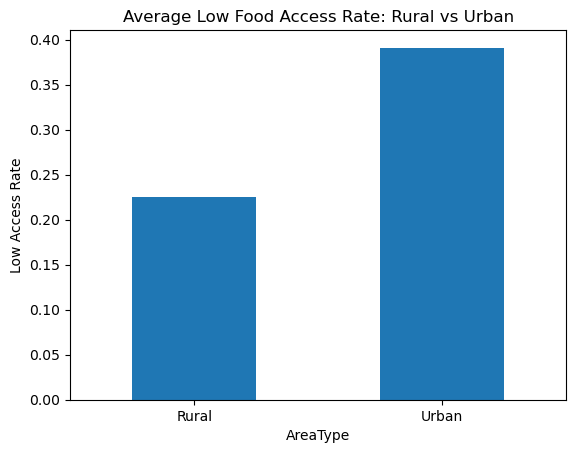

In [14]:
import matplotlib.pyplot as plt

df.groupby('AreaType')['low_access_rate'].mean().plot(kind='bar')
plt.title("Average Low Food Access Rate: Rural vs Urban")
plt.xticks([0,1], ['Rural', 'Urban'], rotation=0)
plt.ylabel("Low Access Rate")
plt.show()

Urban census tracts have a higher average low food access rate (39.1%) compared to rural tracts (22.5%). This suggests that food access issues are not limited to rural areas and may be more concentrated in urban populations.

Compare ONLY low-income tracts

In [15]:
df.groupby('LowIncomeTracts')['low_access_rate'].mean()

LowIncomeTracts
0    0.389247
1    0.318126
Name: low_access_rate, dtype: float64

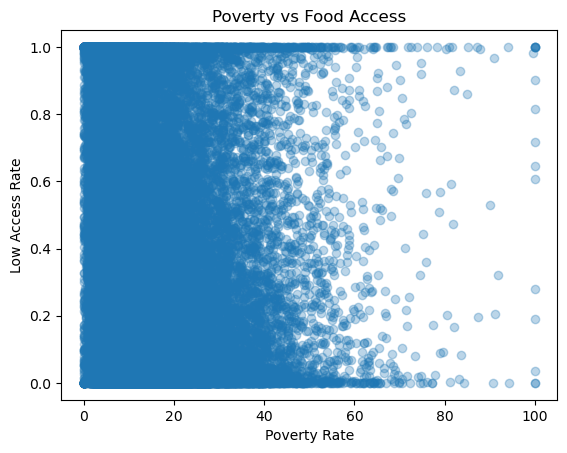

In [16]:
plt.scatter(df['PovertyRate'], df['low_access_rate'], alpha=0.3)
plt.xlabel("Poverty Rate")
plt.ylabel("Low Access Rate")
plt.title("Poverty vs Food Access")
plt.show()

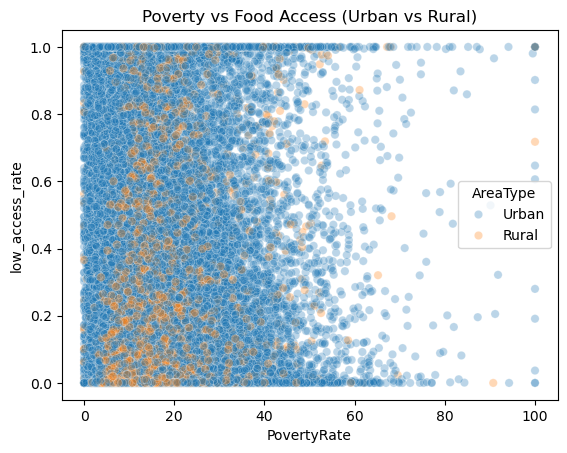

In [59]:
import seaborn as sns

sns.scatterplot(
    data=df,
    x='PovertyRate',
    y='low_access_rate',
    hue='AreaType',
    alpha=0.3
)
plt.title("Poverty vs Food Access (Urban vs Rural)")
plt.show()

In [60]:
df['AreaType'].value_counts()

AreaType
Urban    55169
Rural    17362
Name: count, dtype: int64

In [61]:
df.groupby('Urban')['low_access_rate'].mean()

Urban
0    0.225409
1    0.391026
Name: low_access_rate, dtype: float64

In [62]:
df.groupby('AreaType')['low_access_rate'].mean()

AreaType
Rural    0.225409
Urban    0.391026
Name: low_access_rate, dtype: float64

In [63]:
df[['low_access_rate', 'MedianFamilyIncome', 'PovertyRate']].corr()

,low_access_rate,MedianFamilyIncome,PovertyRate
low_access_rate,1.000000,0.115744,-0.095765
MedianFamilyIncome,0.115744,1.000000,-0.657712
PovertyRate,-0.095765,-0.657712,1.000000


In [64]:
df.groupby('AreaType')[['low_access_rate', 'PovertyRate']].corr()

low_access_rate  PovertyRate
AreaType                                              
Rural    low_access_rate         1.000000     0.065547
         PovertyRate             0.065547     1.000000
Urban    low_access_rate         1.000000    -0.111802
         PovertyRate            -0.111802     1.000000

In [65]:
df['FoodDesert'] = df['LILATracts_1And10'].map({
    0: 'Not Food Desert',
    1: 'Food Desert'
})

In [66]:
df[['Urban', 'LILATracts_1And10']].head(5)

,Urban,LILATracts_1And10
0,1,0
1,1,1
2,1,0
3,1,0
4,1,0


In [67]:
pd.crosstab(df['AreaType'], df['FoodDesert'], normalize='index')

FoodDesert,Food Desert,Not Food Desert
AreaType,,
Rural,0.077871,0.922129
Urban,0.143940,0.856060


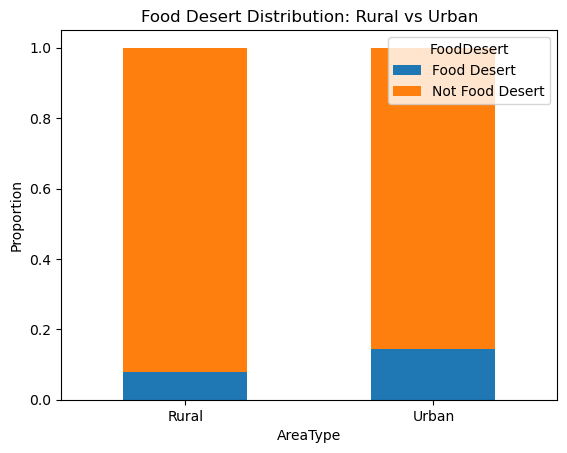

In [68]:
pd.crosstab(df['AreaType'], df['FoodDesert'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Food Desert Distribution: Rural vs Urban")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

In [69]:
df.groupby('FoodDesert')['low_access_rate'].mean()

FoodDesert
Food Desert        0.519753
Not Food Desert    0.318317
Name: low_access_rate, dtype: float64

In [70]:
df[['low_access_rate', 'lakids10share', 'laseniors10share']].corr()

,low_access_rate,lakids10share,laseniors10share
low_access_rate,1.000000,0.815567,0.778443
lakids10share,0.815567,1.000000,0.790211
laseniors10share,0.778443,0.790211,1.000000


In [71]:
df.groupby('LILATracts_Vehicle')['low_access_rate'].mean()

LILATracts_Vehicle
0    0.360543
1    0.370900
Name: low_access_rate, dtype: float64

In [72]:
df.groupby('LILATracts_Vehicle')['low_access_rate'].mean()

LILATracts_Vehicle
0    0.360543
1    0.370900
Name: low_access_rate, dtype: float64

In [73]:
df.sort_values('low_access_rate', ascending=False)[
    ['State', 'County', 'low_access_rate']
].head(10)

,State,County,low_access_rate
36481,Minnesota,Washington County,1.0
36480,Minnesota,Washington County,1.0
19807,Georgia,Muscogee County,1.0
59920,Tennessee,Davidson County,1.0
64570,Texas,Jefferson County,1.0
53907,Oklahoma,Tulsa County,1.0
41359,New Jersey,Hudson County,1.0
57393,Pennsylvania,Philadelphia County,1.0
32051,Massachusetts,Plymouth County,1.0
61260,Texas,Bee County,1.0


In [74]:
state_data = df.groupby('State')['low_access_rate'].mean().sort_values(ascending=False)
state_data.head(10)

State
New Hampshire    0.460586
Alaska           0.451619
Massachusetts    0.438738
Connecticut      0.438317
New Mexico       0.424335
New Jersey       0.422849
Hawaii           0.413402
Arizona          0.409229
Delaware         0.408132
Nevada           0.402871
Name: low_access_rate, dtype: float64

In [75]:
df[['low_access_rate', 'MedianFamilyIncome', 'PovertyRate']].corr()

,low_access_rate,MedianFamilyIncome,PovertyRate
low_access_rate,1.000000,0.115744,-0.095765
MedianFamilyIncome,0.115744,1.000000,-0.657712
PovertyRate,-0.095765,-0.657712,1.000000


In [76]:
df.groupby('LILATracts_Vehicle')['low_access_rate'].mean()

LILATracts_Vehicle
0    0.360543
1    0.370900
Name: low_access_rate, dtype: float64

In [77]:
df.sort_values('low_access_rate', ascending=False)[
    ['State', 'County', 'low_access_rate']
].head(10)

,State,County,low_access_rate
36481,Minnesota,Washington County,1.0
36480,Minnesota,Washington County,1.0
19807,Georgia,Muscogee County,1.0
59920,Tennessee,Davidson County,1.0
64570,Texas,Jefferson County,1.0
53907,Oklahoma,Tulsa County,1.0
41359,New Jersey,Hudson County,1.0
57393,Pennsylvania,Philadelphia County,1.0
32051,Massachusetts,Plymouth County,1.0
61260,Texas,Bee County,1.0


In [90]:
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT',
    'Delaware': 'DE', 'District of Columbia': 'DC', 'Florida': 'FL',
    'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL',
    'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS', 'Kentucky': 'KY',
    'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN',
    'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT',
    'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH',
    'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX',
    'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA',
    'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY'
}

In [91]:
state_data['StateCode'] = state_data['State'].map(state_abbrev)

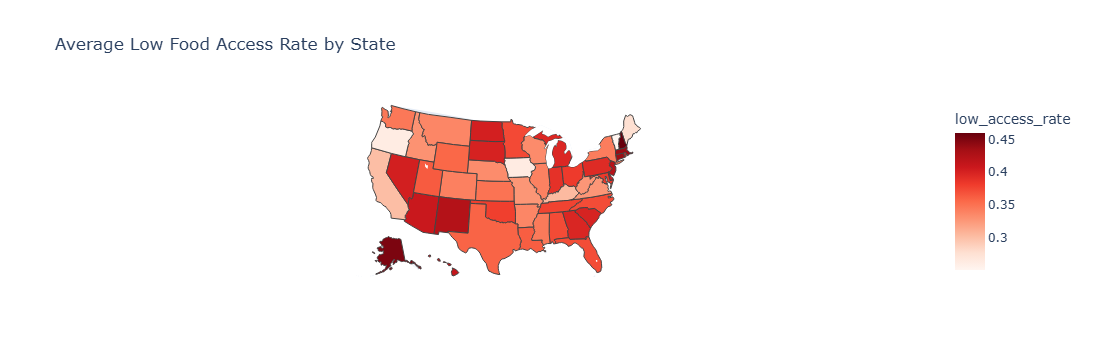

In [94]:
fig = px.choropleth(
    state_data,
    locations='StateCode',  # 👈 use this now
    locationmode='USA-states',
    color='low_access_rate',
    scope='usa',
    color_continuous_scale='Reds',
    title='Average Low Food Access Rate by State'
)

fig.show()

In [95]:
state_data['State'].unique()[:10]

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida'], dtype=object)

In [96]:
state_data[['State', 'StateCode']].head()

,State,StateCode
0,Alabama,AL
1,Alaska,AK
2,Arizona,AZ
3,Arkansas,AR
4,California,CA


In [99]:
state_data['Appalachia_only'] = state_data.apply(
    lambda row: row['low_access_rate'] if row['Appalachia'] else None,
    axis=1
)

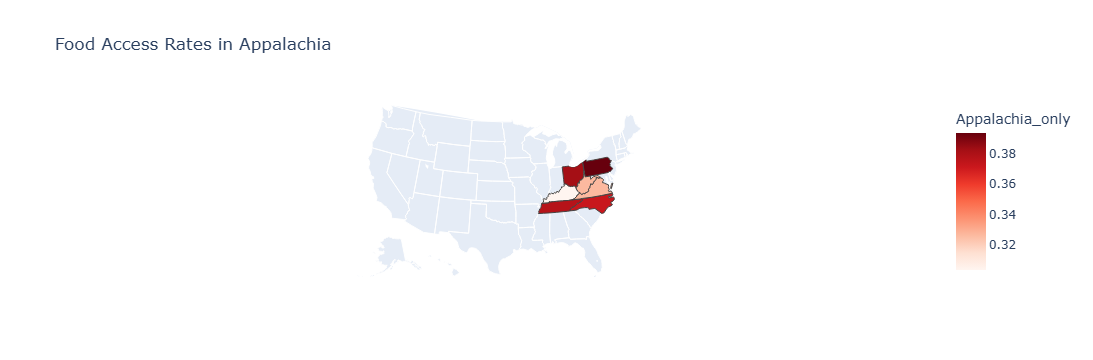

In [105]:
import plotly.express as px

fig = px.choropleth(
    state_data,
    locations='StateCode',
    locationmode='USA-states',
    color='Appalachia_only',  # 👈 only colors Appalachia
    scope='usa',
    color_continuous_scale='Reds',
    title='Food Access Rates in Appalachia'
)

fig.show()

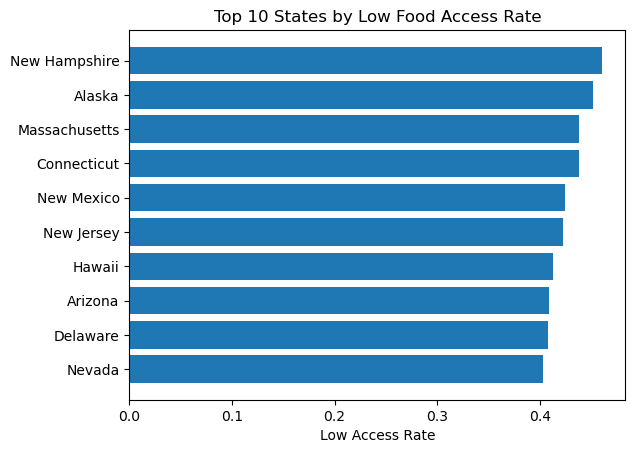

In [106]:
top_states = state_data.sort_values(
    'low_access_rate', ascending=False
).head(10)

import matplotlib.pyplot as plt

plt.figure()
plt.barh(top_states['State'], top_states['low_access_rate'])
plt.title("Top 10 States by Low Food Access Rate")
plt.xlabel("Low Access Rate")
plt.gca().invert_yaxis()
plt.show()

In [116]:
appalachia_states = [
    'West Virginia', 'Kentucky', 'Tennessee',
    'Virginia', 'North Carolina', 'Ohio', 'Pennsylvania'
]

df['Appalachia'] = df['State'].isin(appalachia_states)

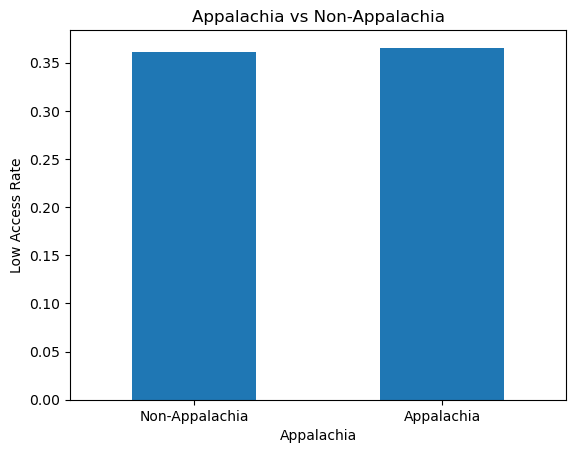

In [117]:
df.groupby('Appalachia')['low_access_rate'].mean().plot(kind='bar')

plt.title("Appalachia vs Non-Appalachia")
plt.xticks([0,1], ['Non-Appalachia', 'Appalachia'], rotation=0)
plt.ylabel("Low Access Rate")
plt.show()

In [118]:
df[df['Appalachia'] == True]['State'].unique()

array(['Kentucky', 'North Carolina', 'Ohio', 'Pennsylvania', 'Tennessee',
       'Virginia', 'West Virginia'], dtype=object)

Does lack of vehicle access increase food insecurity?

In [119]:
df.groupby('HUNVFlag')['low_access_rate'].mean()

HUNVFlag
0    0.356820
1    0.378237
Name: low_access_rate, dtype: float64

In [120]:
df[['MedianFamilyIncome', 'low_access_rate']].corr()

,MedianFamilyIncome,low_access_rate
MedianFamilyIncome,1.000000,0.115744
low_access_rate,0.115744,1.000000


In [121]:
df['VehicleAccess'] = df['HUNVFlag'].map({
    0: 'Has Vehicle',
    1: 'No Vehicle'
})

In [122]:
df.groupby('VehicleAccess')['low_access_rate'].mean()

VehicleAccess
Has Vehicle    0.356820
No Vehicle     0.378237
Name: low_access_rate, dtype: float64

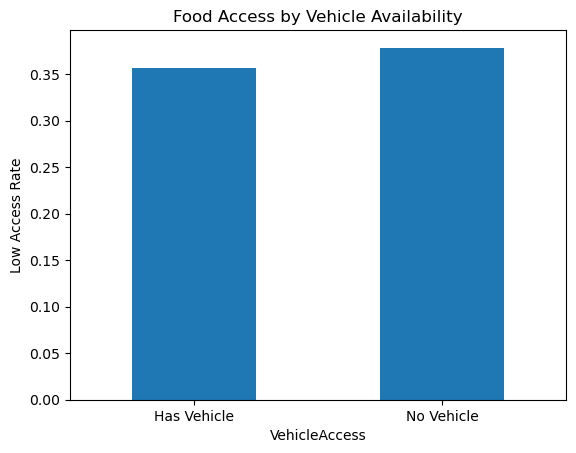

In [123]:
df.groupby('VehicleAccess')['low_access_rate'].mean().plot(kind='bar')

plt.title("Food Access by Vehicle Availability")
plt.ylabel("Low Access Rate")
plt.xticks(rotation=0)
plt.show()

In [124]:
pd.crosstab(
    df['AreaType'],
    df['VehicleAccess'],
    values=df['low_access_rate'],
    aggfunc='mean'
)

VehicleAccess,Has Vehicle,No Vehicle
AreaType,,
Rural,0.234166,0.181263
Urban,0.386424,0.403218
